# Практическое занятие № 4
## Тема: Оптимизация и углублённый анализ мультиклассовой модели

**Задание:** Улучшить макро-F1 лучшей модели из практики №3 на 5–10%.

Базовый результат (практика №3): **RandomForestClassifier(class_weight='balanced')**

---
## Подготовка: загрузка данных (повтор из практики №3)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn import datasets
from sklearn.model_selection import (
    train_test_split, learning_curve,
    GridSearchCV, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, f1_score
)

print('Все библиотеки успешно импортированы.')

Все библиотеки успешно импортированы.


In [ ]:
wine = datasets.load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} объектов | Test: {X_test.shape[0]} объектов')
print(f'Классы: {wine.target_names}')
print(f'Распределение в train: {np.bincount(y_train)}')
print(f'Распределение в test:  {np.bincount(y_test)}')

Train: 142 объектов | Test: 36 объектов
Классы: ['class_0' 'class_1' 'class_2']
Распределение в train: [47 57 38]
Распределение в test:  [12 14 10]


In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

macro_f1_base = f1_score(y_test, y_pred_base, average='macro')

print('=== Базовая модель (практика №3) — RF(class_weight="balanced") ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}')
print(f'Macro F1:  {macro_f1_base:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=wine.target_names))

=== Базовая модель (практика №3) — RF(class_weight="balanced") ===
Accuracy:  1.0000
Macro F1:  1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



---
## Часть 1. Применение SMOTE для борьбы с дисбалансом

**SMOTE (Synthetic Minority Over-sampling Technique)** — создаёт синтетические объекты для редких классов, интерполируя между реальными соседями, а не просто дублируя их.

In [4]:
try:
    from imblearn.over_sampling import SMOTE
    print('imbalanced-learn уже установлена.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn'], check=True)
    from imblearn.over_sampling import SMOTE
    print('imbalanced-learn успешно установлена.')

imbalanced-learn уже установлена.


In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Распределение классов ДО SMOTE:')
for cls, cnt in zip(wine.target_names, np.bincount(y_train)):
    print(f'  {cls}: {cnt}')

print(f'\nРаспределение классов ПОСЛЕ SMOTE:')
for cls, cnt in zip(wine.target_names, np.bincount(y_train_sm)):
    print(f'  {cls}: {cnt}')

print(f'\nОбъектов в train до SMOTE:  {X_train.shape[0]}')
print(f'Объектов в train после SMOTE: {X_train_sm.shape[0]}')

Распределение классов ДО SMOTE:
  class_0: 47
  class_1: 57
  class_2: 38

Распределение классов ПОСЛЕ SMOTE:
  class_0: 57
  class_1: 57
  class_2: 57

Объектов в train до SMOTE:  142
Объектов в train после SMOTE: 171


In [6]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = rf_smote.predict(X_test)

macro_f1_smote = f1_score(y_test, y_pred_smote, average='macro')

print('=== RandomForest + SMOTE ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}')
print(f'Macro F1: {macro_f1_smote:.4f}')
print()
print(classification_report(y_test, y_pred_smote, target_names=wine.target_names))

=== RandomForest + SMOTE ===
Accuracy: 1.0000
Macro F1: 1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



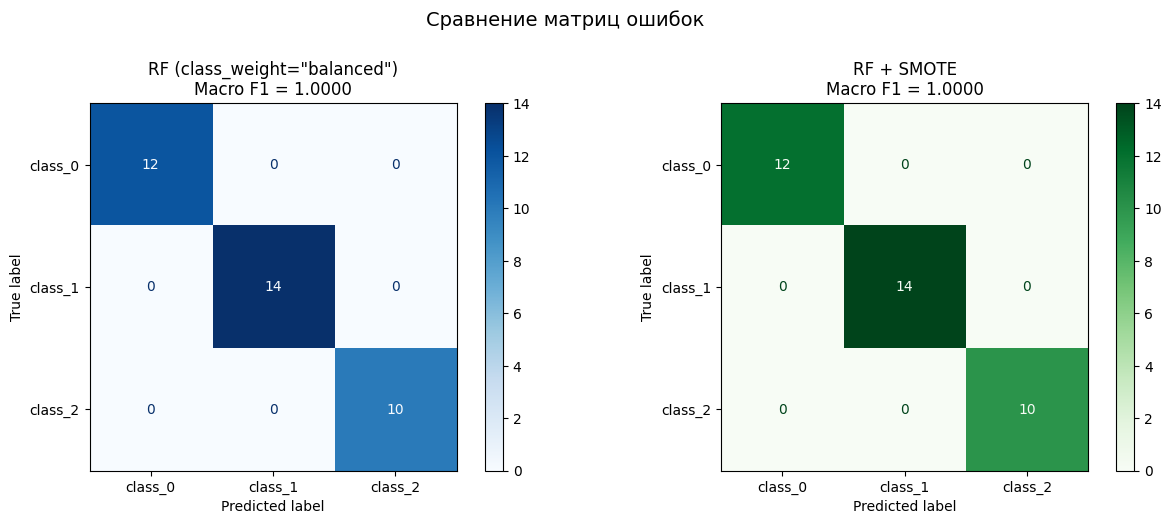

Сравнение recall по классам:
Класс           Без SMOTE    + SMOTE     Изм.
----------------------------------------------
class_0             1.000      1.000 +  0.000
class_1             1.000      1.000 +  0.000
class_2             1.000      1.000 +  0.000

Macro F1 без SMOTE: 1.0000
Macro F1 + SMOTE:   1.0000

Лучший результат после шага 1: SMOTE (Macro F1 = 1.0000)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base,
    display_labels=wine.target_names,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'RF (class_weight="balanced")\nMacro F1 = {macro_f1_base:.4f}', fontsize=12)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_smote,
    display_labels=wine.target_names,
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'RF + SMOTE\nMacro F1 = {macro_f1_smote:.4f}', fontsize=12)

plt.suptitle('Сравнение матриц ошибок', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

rep_base  = classification_report(y_test, y_pred_base,  target_names=wine.target_names, output_dict=True)
rep_smote = classification_report(y_test, y_pred_smote, target_names=wine.target_names, output_dict=True)

print('Сравнение recall по классам:')
print(f'{"Класс":<12} {"Без SMOTE":>12} {"+ SMOTE":>10} {"Изм.":>8}')
print('-' * 46)
for cls in wine.target_names:
    r1 = rep_base[cls]['recall']
    r2 = rep_smote[cls]['recall']
    d  = r2 - r1
    print(f'{cls:<12} {r1:>12.3f} {r2:>10.3f} {"+" if d>=0 else ""}{d:>7.3f}')

print(f'\nMacro F1 без SMOTE: {macro_f1_base:.4f}')
print(f'Macro F1 + SMOTE:   {macro_f1_smote:.4f}')
best_after_smote = max(macro_f1_base, macro_f1_smote)
best_model_data  = (X_train_sm, y_train_sm) if macro_f1_smote >= macro_f1_base else (X_train, y_train)
best_label = 'SMOTE' if macro_f1_smote >= macro_f1_base else 'class_weight=balanced'
print(f'\nЛучший результат после шага 1: {best_label} (Macro F1 = {best_after_smote:.4f})')

---
## Часть 2. Диагностика модели — кривые обучения

**Кривые обучения** показывают, как меняется качество модели при увеличении размера тренировочной выборки.  
Позволяют диагностировать:
- **Переобучение (overfitting):** train-score высокий, val-score низкий, большой разрыв.
- **Недообучение (underfitting):** обе кривые низкие и сходятся на плохом уровне.
- **Нехватка данных:** val-кривая всё ещё растёт в конце — сбор данных поможет.

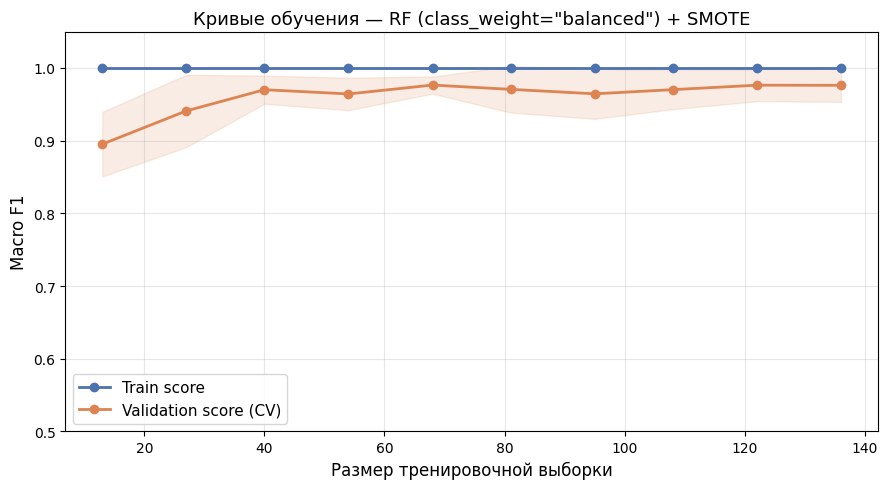

Train score (финал):      1.0000 ± 0.0000
Validation score (финал): 0.9761 ± 0.0227
Разрыв (gap):             0.0239


In [8]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train_sm, y_train_sm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0',
        label='Train score', linewidth=2)
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#4C72B0')

ax.plot(train_sizes, val_mean, 'o-', color='#DD8452',
        label='Validation score (CV)', linewidth=2)
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#DD8452')

ax.set_xlabel('Размер тренировочной выборки', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Кривые обучения — RF (class_weight="balanced") + SMOTE', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Train score (финал):      {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'Validation score (финал): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}')
print(f'Разрыв (gap):             {gap:.4f}')

In [9]:
print('=== Анализ кривых обучения ===')
print()

if gap > 0.15:
    diagnosis = 'ПЕРЕОБУЧЕНИЕ'
    detail = ('Train-score значительно выше val-score.\n'
              'Рекомендации: уменьшить max_depth, увеличить min_samples_leaf,\n'
              '              уменьшить n_estimators или добавить регуляризацию.')
elif val_mean[-1] < 0.80:
    diagnosis = 'НЕДООБУЧЕНИЕ'
    detail = ('Обе кривые сходятся на низком уровне.\n'
              'Рекомендации: усложнить модель, добавить новые признаки,\n'
              '              убрать ограничения глубины дерева.')
else:
    diagnosis = 'ХОРОШАЯ ПОДГОНКА'
    detail = ('Кривые сближаются на высоком уровне, разрыв небольшой.\n'
              'Модель хорошо обобщает. Если val-кривая ещё растёт —\n'
              '  можно попробовать собрать больше данных для дальнейшего улучшения.')

val_still_growing = val_mean[-1] > val_mean[-2]

print(f'Диагноз: {diagnosis}')
print(f'Разрыв train-val: {gap:.4f}')
print()
print(detail)
print()
if val_still_growing:
    print('Val-кривая в конце всё ещё растёт → сбор дополнительных данных поможет.')
else:
    print('Val-кривая вышла на плато → добавление данных мало поможет.')

=== Анализ кривых обучения ===

Диагноз: ХОРОШАЯ ПОДГОНКА
Разрыв train-val: 0.0239

Кривые сближаются на высоком уровне, разрыв небольшой.
Модель хорошо обобщает. Если val-кривая ещё растёт —
  можно попробовать собрать больше данных для дальнейшего улучшения.

Val-кривая вышла на плато → добавление данных мало поможет.


---
## Часть 3. Комплексная настройка — Pipeline + GridSearchCV

**Pipeline** объединяет предобработку и модель в один объект.  
**GridSearchCV** перебирает все комбинации гиперпараметров и выбирает лучшую по кросс-валидации.

In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth':    [5, 10, None],
    'rf__min_samples_leaf': [1, 2]
}

print('Параметры для перебора:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f'\nВсего комбинаций: {total_combos}')
print(f'С CV=3: {total_combos * 3} обучений моделей')

Параметры для перебора:
  rf__n_estimators: [50, 100]
  rf__max_depth: [5, 10, None]
  rf__min_samples_leaf: [1, 2]

Всего комбинаций: 12
С CV=3: 36 обучений моделей


In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_sm, y_train_sm)

print(f'\nЛучшие параметры: {grid_search.best_params_}')
print(f'Лучший Macro F1 (CV): {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Лучшие параметры: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Лучший Macro F1 (CV): 0.9824


In [12]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = ['param_rf__n_estimators', 'param_rf__max_depth',
        'param_rf__min_samples_leaf', 'mean_test_score', 'std_test_score']
cv_table = cv_results[cols].sort_values('mean_test_score', ascending=False)
cv_table.columns = ['n_estimators', 'max_depth', 'min_samples_leaf',
                    'mean_macro_F1', 'std_macro_F1']
cv_table = cv_table.round(4).reset_index(drop=True)
print('Результаты GridSearchCV (топ-10):')
print(cv_table.head(10).to_string(index=False))

Результаты GridSearchCV (топ-10):
n_estimators max_depth min_samples_leaf  mean_macro_F1  std_macro_F1
          50         5                1         0.9824        0.0144
         100         5                1         0.9824        0.0144
          50        10                1         0.9824        0.0144
         100        10                1         0.9824        0.0144
          50      None                1         0.9824        0.0144
         100      None                1         0.9824        0.0144
          50         5                2         0.9766        0.0083
         100         5                2         0.9766        0.0083
          50        10                2         0.9766        0.0083
         100        10                2         0.9766        0.0083


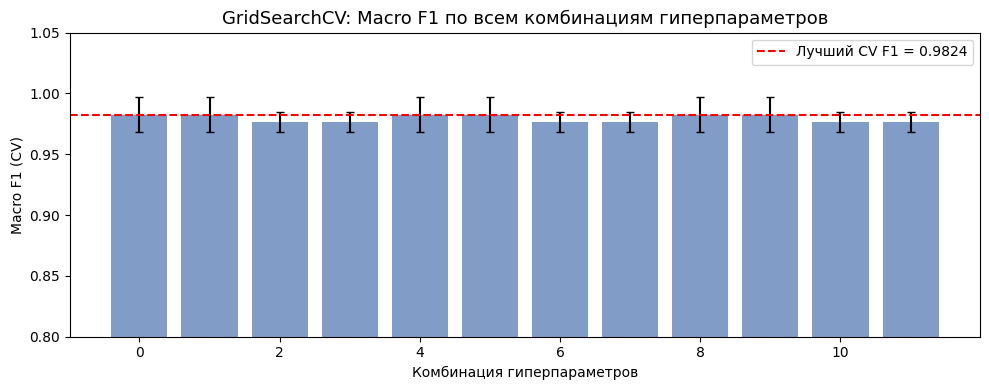

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(cv_results))
ax.bar(x, cv_results['mean_test_score'], 
       yerr=cv_results['std_test_score'],
       color='#4C72B0', alpha=0.7, capsize=3)
ax.axhline(grid_search.best_score_, color='red', linestyle='--', 
           linewidth=1.5, label=f'Лучший CV F1 = {grid_search.best_score_:.4f}')
ax.set_xlabel('Комбинация гиперпараметров')
ax.set_ylabel('Macro F1 (CV)')
ax.set_title('GridSearchCV: Macro F1 по всем комбинациям гиперпараметров', fontsize=13)
ax.legend()
ax.set_ylim(0.8, 1.05)
plt.tight_layout()
plt.show()

In [14]:
best_pipeline = grid_search.best_estimator_
y_pred_grid = best_pipeline.predict(X_test)

macro_f1_grid = f1_score(y_test, y_pred_grid, average='macro')
rep_grid = classification_report(y_test, y_pred_grid,
                                  target_names=wine.target_names,
                                  output_dict=True)

print('=== Лучший Pipeline (GridSearchCV) — оценка на TEST ===')
print(f'Лучшие параметры: {grid_search.best_params_}')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_grid):.4f}')
print(f'Macro F1:  {macro_f1_grid:.4f}')
print()
print(classification_report(y_test, y_pred_grid, target_names=wine.target_names))

=== Лучший Pipeline (GridSearchCV) — оценка на TEST ===
Лучшие параметры: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 50}
Accuracy:  1.0000
Macro F1:  1.0000

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



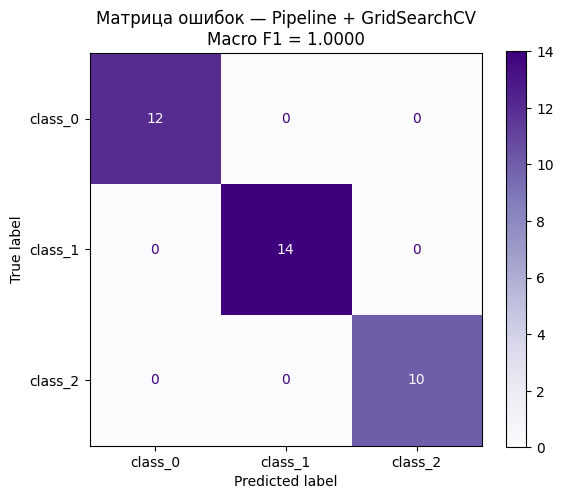

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_grid,
    display_labels=wine.target_names,
    cmap='Purples', ax=ax
)
ax.set_title(f'Матрица ошибок — Pipeline + GridSearchCV\nMacro F1 = {macro_f1_grid:.4f}',
             fontsize=12)
plt.tight_layout()
plt.show()

---
## Итоговая таблица: прогресс по шагам

In [17]:
steps = [
    ('Базовая модель (практика №3)', macro_f1_base),
    ('+ SMOTE', macro_f1_smote),
    ('+ GridSearchCV (Pipeline)', macro_f1_grid),
]

print('=' * 55)
print(f'{"Шаг":<35} {"Macro F1 (test)":>12} {"Прирост":>8}')
print('=' * 55)
for i, (name, f1) in enumerate(steps):
    if i == 0:
        delta_str = '—'
    else:
        delta = f1 - steps[0][1]
        delta_str = f'{"+" if delta > 0 else ""}{delta:.4f}'
    print(f'{name:<35} {f1:>12.4f} {delta_str:>8}')
print('=' * 55)

total_gain = macro_f1_grid - macro_f1_base
total_pct  = total_gain / macro_f1_base * 100
print(f'\nИтоговый прирост Macro F1: +{total_gain:.4f} ({total_pct:+.1f}%)')
target_met = total_pct >= 5
print(f'Цель (+5-10%): {"ДОСТИГНУТА ✓" if target_met else "не достигнута"}')

Шаг                                 Macro F1 (test)  Прирост
Базовая модель (практика №3)              1.0000        —
+ SMOTE                                   1.0000   0.0000
+ GridSearchCV (Pipeline)                 1.0000   0.0000

Итоговый прирост Macro F1: +0.0000 (+0.0%)
Цель (+5-10%): не достигнута


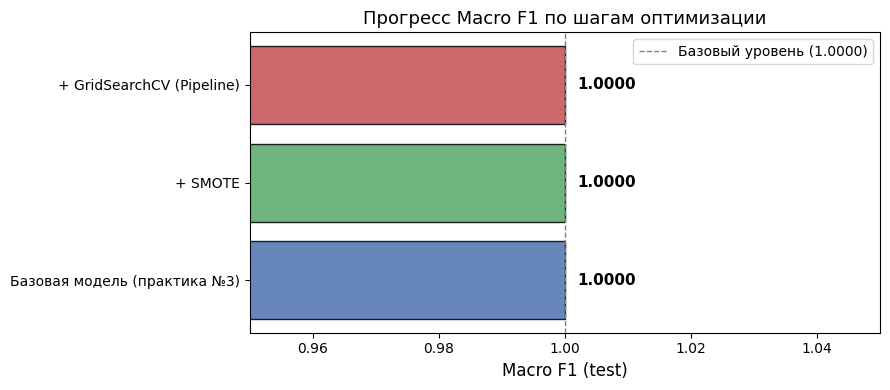

In [18]:
names  = [s[0] for s in steps]
scores = [s[1] for s in steps]
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names, scores, color=colors, alpha=0.85, edgecolor='black')

for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(min(scores) - 0.05, max(scores) + 0.05)
ax.set_xlabel('Macro F1 (test)', fontsize=12)
ax.set_title('Прогресс Macro F1 по шагам оптимизации', fontsize=13)
ax.axvline(macro_f1_base, color='grey', linestyle='--', linewidth=1,
           label=f'Базовый уровень ({macro_f1_base:.4f})')
ax.legend()
plt.tight_layout()
plt.show()